Saving leaf_data.csv to leaf_data (2).csv


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(



=== MLP-All ===
0.918918918918919 0.9527027027027027 0.918918918918919 0.9163449163449162


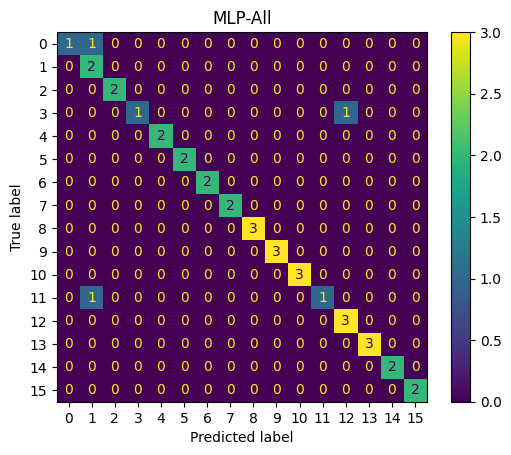


=== RF-All ===
0.8918918918918919 0.9256756756756757 0.8918918918918919 0.8893178893178894


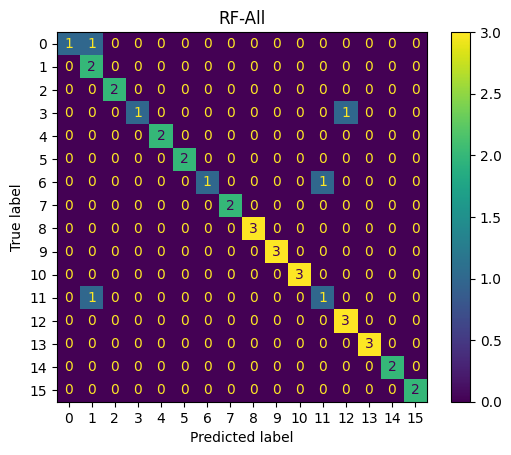

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(



=== MLP-Shape ===
0.7297297297297297 0.7117117117117117 0.7297297297297297 0.7099099099099099


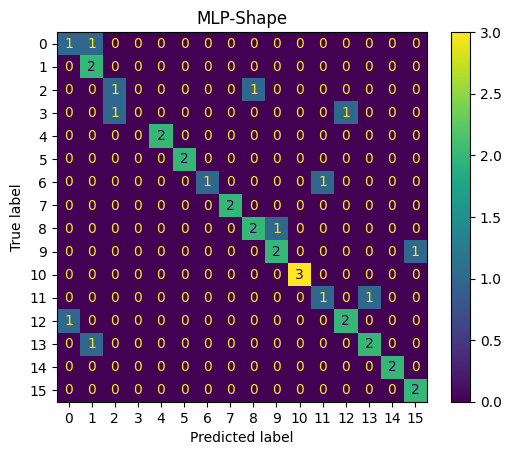


=== RF-Shape ===
0.7837837837837838 0.8540540540540541 0.7837837837837838 0.7783783783783783


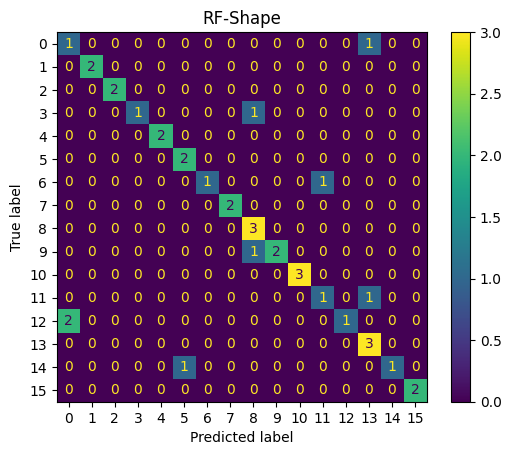

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(



=== MLP-Texture ===
0.5135135135135135 0.545045045045045 0.5135135135135135 0.49858429858429865


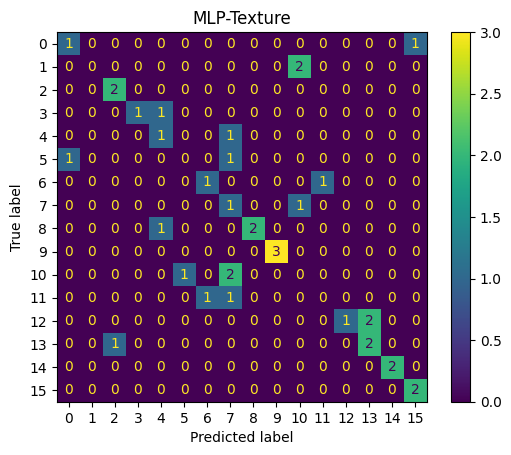


=== RF-Texture ===
0.3783783783783784 0.3387387387387387 0.3783783783783784 0.3468468468468468


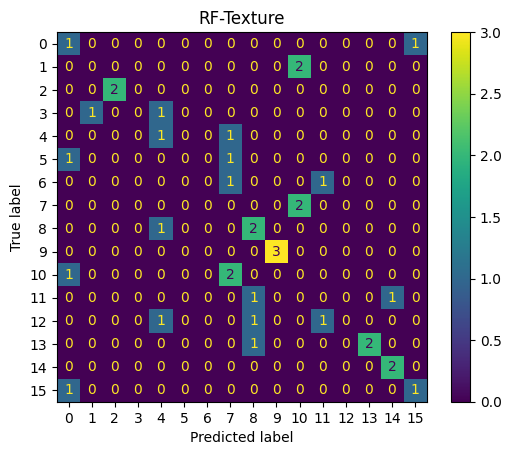

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(



=== MLP-Selected ===
0.7837837837837838 0.786036036036036 0.7837837837837838 0.7644787644787645


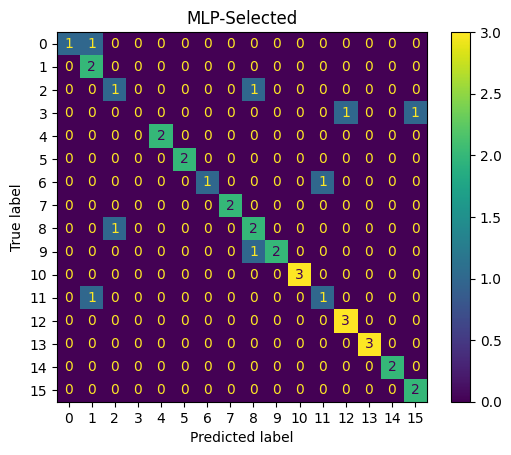


=== RF-Selected ===
0.8918918918918919 0.9166666666666666 0.8918918918918919 0.8857142857142858


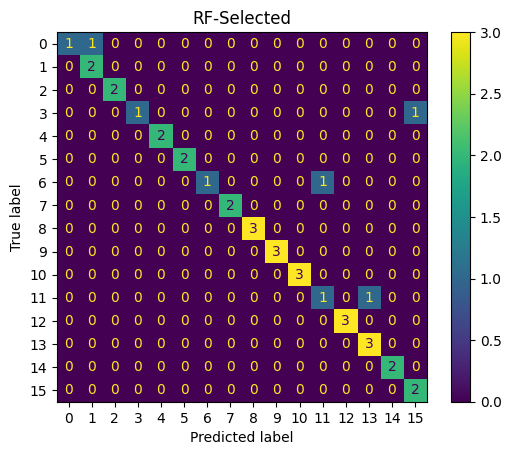

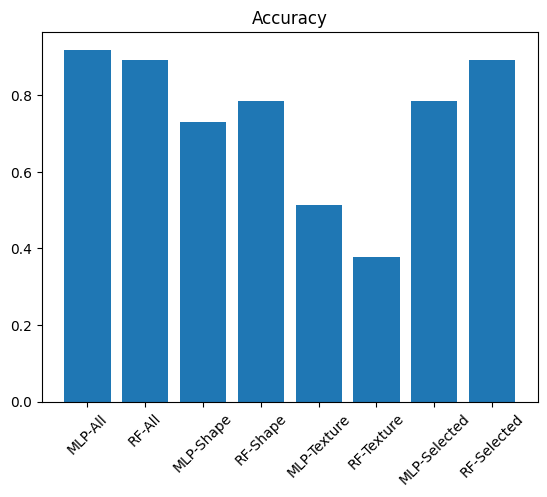

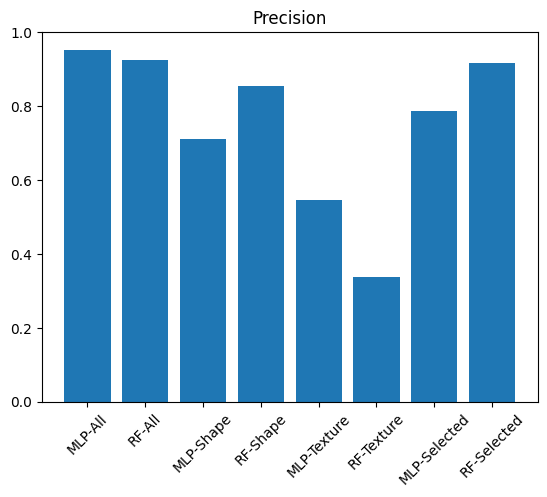

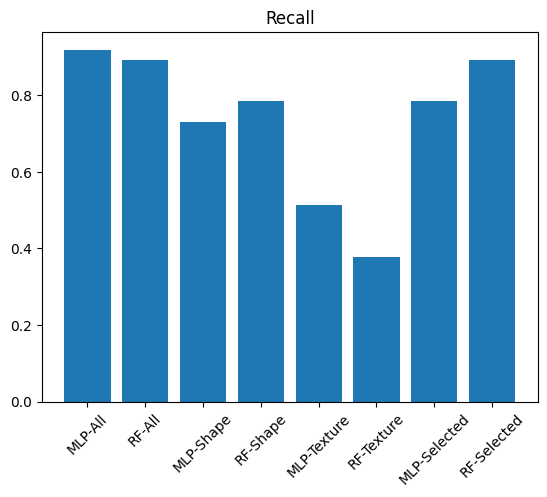

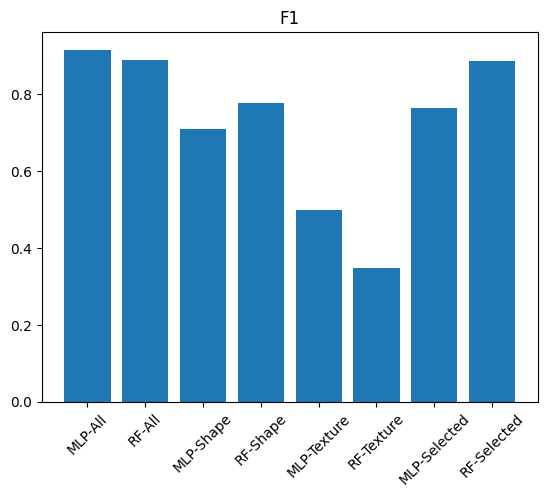

In [4]:
# ============================================================
# Plant Leaf Classification using MLP Neural Network
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

from google.colab import files
uploaded = files.upload()


df = pd.read_csv(list(uploaded.keys())[0])

df = df.drop_duplicates()


df = df.drop(columns=['s[ecies'])

y = df.iloc[:, 0]
X = df.iloc[:, 1:]

shape_features = X.iloc[:, 0:8]
texture_features = X.iloc[:, 8:14]
feature_selection_features = X.iloc[:, list(range(0,8)) + [9,10]]

mlp_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(max_iter=500, random_state=42))
])

rf_pipeline = Pipeline([
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
])

def evaluate(model, X_subset, label):
    X_train, X_test, y_train, y_test = train_test_split(
        X_subset, y, test_size=0.2, random_state=42, stratify=y
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    print(f"\n=== {label} ===")
    print(acc, prec, rec, f1)

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm).plot()
    plt.title(label)
    plt.show()

    return [acc, prec, rec, f1]

results_A = {}

for data, label in zip(
    [X, shape_features, texture_features, feature_selection_features],
    ['All','Shape','Texture','Selected']
):
    results_A[f"MLP-{label}"] = evaluate(mlp_pipeline, data, f"MLP-{label}")
    results_A[f"RF-{label}"] = evaluate(rf_pipeline, data, f"RF-{label}")

metrics = ['Accuracy','Precision','Recall','F1']
vals = np.array(list(results_A.values()))

for i, m in enumerate(metrics):
    plt.figure()
    plt.bar(results_A.keys(), vals[:, i])
    plt.title(m)
    plt.xticks(rotation=45)
    plt.show()